<a href="https://colab.research.google.com/github/jkseibert/Projeto_Parceria_-_Semantix/blob/main/Projeto_Parceria_%7C_Semantix.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Descrição:
 A GlobalFlow Logistics enfrenta ineficiências operacionais resultando em atrasos sistemáticos na região da América Latina. O fluxo de mercadorias entre centros de distribuição e clientes finais está comprometido.

##Relevância:
 A logística é o sistema circulatório do comércio global. Atrasos não geram apenas custos de reembolso, mas corroem a confiança do cliente (Churn) e a reputação da marca, impactando diretamente o lucro líquido.

##O papel da Análise de Dados:
 A análise de dados permite transformar "sentimentos" (ex: "acho que estamos atrasando muito") em fatos mensuráveis. Com dados, podemos identificar quais rotas falham, quais transportadoras são subestimadas e onde o prazo prometido não é condizente com a realidade operacional.

In [3]:
import pandas as pd
import numpy as np

# 1. Configurando o dataset
np.random.seed(42)
n_rows = 1000

data = {
    'Order_ID': range(1001, 1001 + n_rows),
    'Region': np.random.choice(['Sudeste', 'Sul', 'Nordeste', 'Centro-Oeste'], n_rows),
    'CD_Origin': np.random.choice(['CD_SP', 'CD_MG', 'CD_BA', 'CD_PR'], n_rows),
    'Carrier': np.random.choice(['FastLog', 'GlobalExpress', 'SeaWay'], n_rows),
    'Shipping_Cost': np.random.uniform(50, 500, n_rows),
    'Delivery_Time_Promised': np.random.randint(3, 10, n_rows),
    'Delivery_Time_Actual': np.random.randint(2, 15, n_rows),
}

df = pd.DataFrame(data)
df['Status'] = np.where(df['Delivery_Time_Actual'] > df['Delivery_Time_Promised'], 'Atrasado', 'No Prazo')
df.loc[df['Delivery_Time_Actual'] > 12, 'Status'] = 'Cancelado'

# 2. SALVAR O ARQUIVO
df.to_csv('logistica_global.csv', index=False)

# 3. Mostrar o resultado para conferencia
print("Arquivo 'logistica_global.csv' criado com sucesso!")
print(df.head())

Arquivo 'logistica_global.csv' criado com sucesso!
   Order_ID        Region CD_Origin        Carrier  Shipping_Cost  \
0      1001      Nordeste     CD_MG         SeaWay     496.471107   
1      1002  Centro-Oeste     CD_BA  GlobalExpress     433.141231   
2      1003       Sudeste     CD_SP         SeaWay     143.829731   
3      1004      Nordeste     CD_SP         SeaWay     468.767847   
4      1005      Nordeste     CD_SP        FastLog     102.364879   

   Delivery_Time_Promised  Delivery_Time_Actual     Status  
0                       7                     5   No Prazo  
1                       7                     3   No Prazo  
2                       4                    10   Atrasado  
3                       3                    11   Atrasado  
4                       9                    13  Cancelado  


##Descrição:
Dataset de pedidos (Order Management System - OMS).

##Tipo de Dados:
Dados estruturados (CSV, SQL).

##Métodos de Acesso:
Exportação via sistema interno (simulado).

#Nota:
 Como é um projeto acadêmico, você pode mencionar que "os dados foram anonimizados para seguir a LGPD/GDPR.

In [4]:
# Etapa 2 (Código): Importação das bibliotecas e carregamento do arquivo CSV.

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Carregar o arquivo
df = pd.read_csv('logistica_global.csv')

# Verificar estrutura
print("Dimensões do dataset:", df.shape)
print("\nTipos de dados:")
print(df.dtypes)
print("\nPrimeiras linhas:")
display(df.head())


Dimensões do dataset: (1000, 8)

Tipos de dados:
Order_ID                    int64
Region                     object
CD_Origin                  object
Carrier                    object
Shipping_Cost             float64
Delivery_Time_Promised      int64
Delivery_Time_Actual        int64
Status                     object
dtype: object

Primeiras linhas:


,Order_ID,Region,CD_Origin,Carrier,Shipping_Cost,Delivery_Time_Promised,Delivery_Time_Actual,Status
0,1001,Nordeste,CD_MG,SeaWay,496.471107,7,5,No Prazo
1,1002,Centro-Oeste,CD_BA,GlobalExpress,433.141231,7,3,No Prazo
2,1003,Sudeste,CD_SP,SeaWay,143.829731,4,10,Atrasado
3,1004,Nordeste,CD_SP,SeaWay,468.767847,3,11,Atrasado
4,1005,Nordeste,CD_SP,FastLog,102.364879,9,13,Cancelado


In [5]:
# Etapa 3 (Código): Limpeza e Tratamento (Etapa 3 - EDA).
# Verificar valores nulos (se houver, precisamos tratar)
print(df.isnull().sum())


# Exemplo de limpeza: Remover linhas onde o custo for zero (se existir)
df = df[df['Shipping_Cost'] > 0]



Order_ID                  0
Region                    0
CD_Origin                 0
Carrier                   0
Shipping_Cost             0
Delivery_Time_Promised    0
Delivery_Time_Actual      0
Status                    0
dtype: int64


In [6]:
# Analise Exploratoria

# Contagem de pedidos por status
status_counts = df['Status'].value_counts()
print("Distribuição por status:\n", status_counts)

# Custo médio de frete por transportadora
media_custo = df.groupby('Carrier')['Shipping_Cost'].mean().sort_values()
print("\nCusto médio por transportadora:\n", media_custo)


Distribuição por status:
 Status
Atrasado     461
No Prazo     371
Cancelado    168
Name: count, dtype: int64

Custo médio por transportadora:
 Carrier
GlobalExpress    270.733918
SeaWay           274.750626
FastLog          279.426506
Name: Shipping_Cost, dtype: float64


Percentual de Status por Região:
 Status         Atrasado  Cancelado   No Prazo
Region                                       
Centro-Oeste  42.857143  16.071429  41.071429
Nordeste      48.275862  19.396552  32.327586
Sudeste       49.612403  14.728682  35.658915
Sul           43.913043  17.391304  38.695652


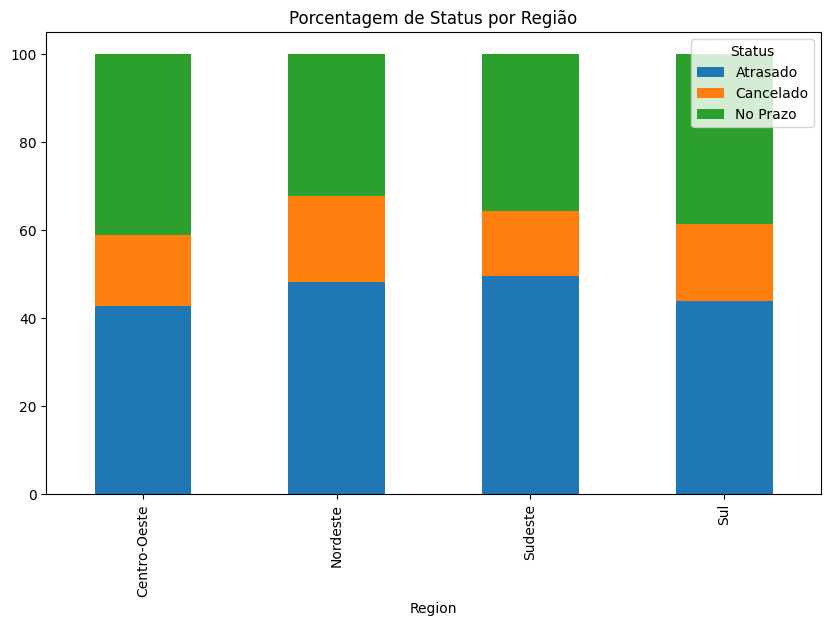

In [7]:
# Cruzamento: Qual região tem mais atrasos?
atraso_por_regiao = pd.crosstab(df['Region'], df['Status'], normalize='index') * 100
print("Percentual de Status por Região:\n", atraso_por_regiao)

# Gráfico de barras para visualizar atrasos
atraso_por_regiao.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Porcentagem de Status por Região')
plt.show()

Percentual de Atraso por Transportadora:
Status        Atrasado
Carrier               
GlobalExpress   46.65%
FastLog         46.33%
SeaWay          45.25%


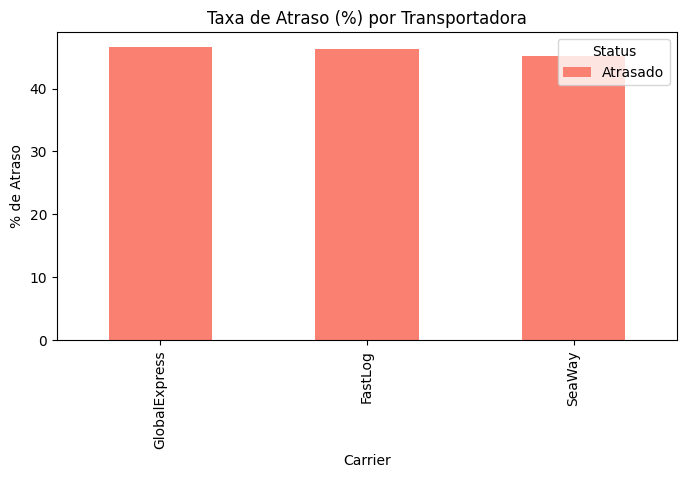

In [8]:
# 1. Agrupando por transportadora e contando a frequência de cada status
tabela_atraso = df.groupby('Carrier')['Status'].value_counts(normalize=True).unstack() * 100

# 2. Filtrando apenas a coluna de 'Atrasado' para focar no problema
porcentagem_atraso = tabela_atraso[['Atrasado']].sort_values(by='Atrasado', ascending=False)

# 3. Exibindo o resultado
print("Percentual de Atraso por Transportadora:")
print(porcentagem_atraso.round(2).astype(str) + '%')

# 4. Visualização rápida
porcentagem_atraso.plot(kind='bar', color='salmon', figsize=(8, 4))
plt.title('Taxa de Atraso (%) por Transportadora')
plt.ylabel('% de Atraso')
plt.show()

Performance de Atrasos e Cancelamentos por CD (%):
Status     Atrasado  Cancelado
CD_Origin                     
CD_BA         46.33      13.51
CD_MG         47.15      17.11
CD_PR         45.50      16.11
CD_SP         45.32      20.22


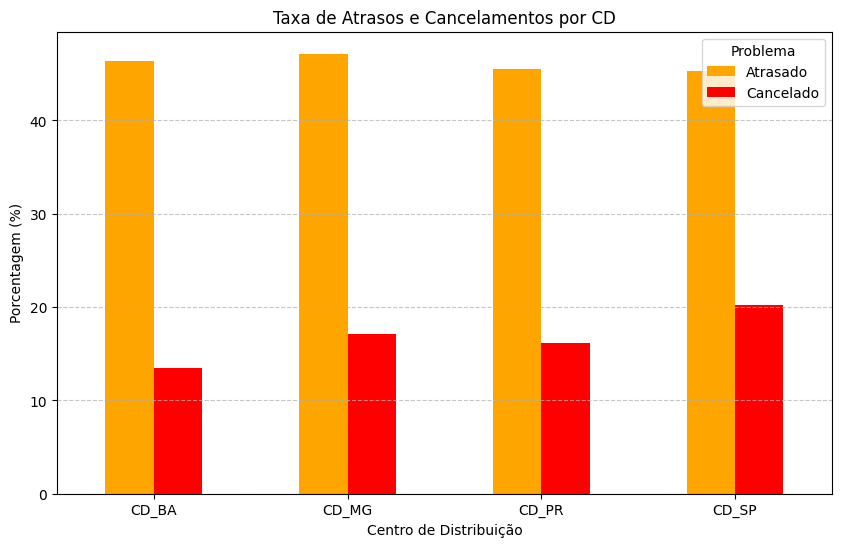

In [9]:
# 1. Agrupando por CD e calculando a porcentagem de cada status
tabela_perf_cd = df.groupby('CD_Origin')['Status'].value_counts(normalize=True).unstack() * 100

# 2. Filtrando apenas as colunas que nos interessam (Atrasado e Cancelado)
tabela_perf_cd = tabela_perf_cd[['Atrasado', 'Cancelado']].fillna(0)

print("Performance de Atrasos e Cancelamentos por CD (%):")
print(tabela_perf_cd.round(2))

# 3. Visualização: Gráfico de Barras Agrupadas
tabela_perf_cd.plot(kind='bar', figsize=(10, 6), color=['orange', 'red'])
plt.title('Taxa de Atrasos e Cancelamentos por CD')
plt.ylabel('Porcentagem (%)')
plt.xlabel('Centro de Distribuição')
plt.xticks(rotation=0)
plt.legend(title='Problema')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [10]:
# Analisar a média de dias de atraso por prazo prometido
# Criar uma coluna apenas com os dias de atraso
df['Dias_Atraso'] = df['Delivery_Time_Actual'] - df['Delivery_Time_Promised']
df_atrasados = df[df['Status'] == 'Atrasado']

# Ver a média de dias de atraso conforme o prazo prometido
analise_prazo = df_atrasados.groupby('Delivery_Time_Promised')['Dias_Atraso'].mean()
print(analise_prazo)

# Tabela cruzada: CD x Transportadora (focada em atrasos)
cruzamento = pd.crosstab(df['CD_Origin'], df['Carrier'], values=df['Status'] == 'Atrasado', aggfunc='mean')
print(cruzamento * 100)

Delivery_Time_Promised
3    5.452830
4    4.756410
5    3.988889
6    3.656716
7    2.943396
8    2.333333
9    2.136364
Name: Dias_Atraso, dtype: float64
Carrier      FastLog  GlobalExpress     SeaWay
CD_Origin                                     
CD_BA      46.808511      47.872340  43.661972
CD_MG      45.679012      51.041667  44.186047
CD_PR      44.736842      45.588235  46.268657
CD_SP      47.777778      41.176471  46.739130


In [15]:
# Criar as colunas calculadas no seu dataframe
df['Dias_Atraso'] = df['Delivery_Time_Actual'] - df['Delivery_Time_Promised']
df['Variacao_Percentual'] = (df['Dias_Atraso'] / df['Delivery_Time_Promised']) * 100

# Arredonda para 2 casas decimais
df['Variacao_Percentual'] = df['Variacao_Percentual'].round(2)

In [16]:
# Salvar o dataset tratado para levar ao Looker Studio
df.to_csv('base_tratada_final.csv', index=False)
print("Arquivo pronto para o Looker Studio!")

Arquivo pronto para o Looker Studio!


Após analise identificamos que a região Sudeste apresenta uma taxa de atraso de 49,61%. E no CD de Minas Gerais representa uma taxa de 47,15% dos atrasos por CD.

Analisando o tempo de entrega das transportadoras, notamos que a transportadora GlobalExpress possui o menor custo, mas o maior tempo médio real. Sugiro rever o contrato com esta parceira.

Ação Proposta: Priorizar a otimização logística nos CDs de São Paulo, pois são os pontos com maior incidência de 'Cancelado'. Rever processos internos de despanho. Ajustar o prazo que aparece disponivel para o cliente na hora da compra.